In [1]:
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd

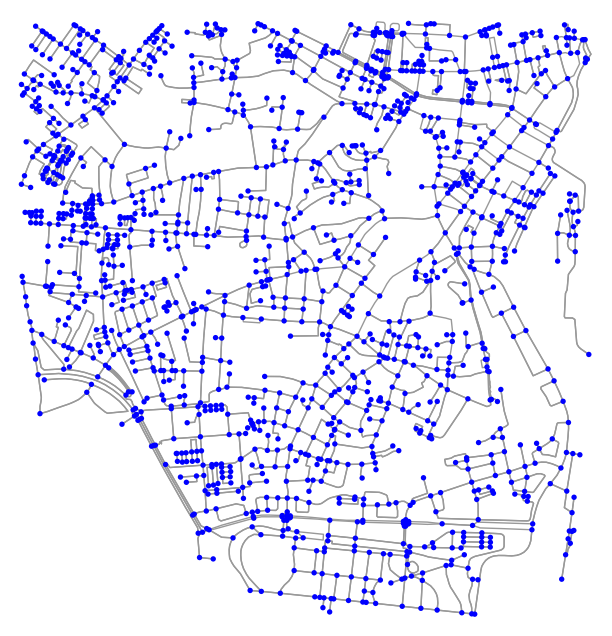

In [2]:
G = ox.graph_from_point(center_point=(38.4259826,141.3012349), network_type='all', dist=1000, simplify=True)
fig, ax = ox.plot_graph(G,node_color='blue',bgcolor='white')
G_proj = ox.project_graph(G)
G_und = G_proj.to_undirected()


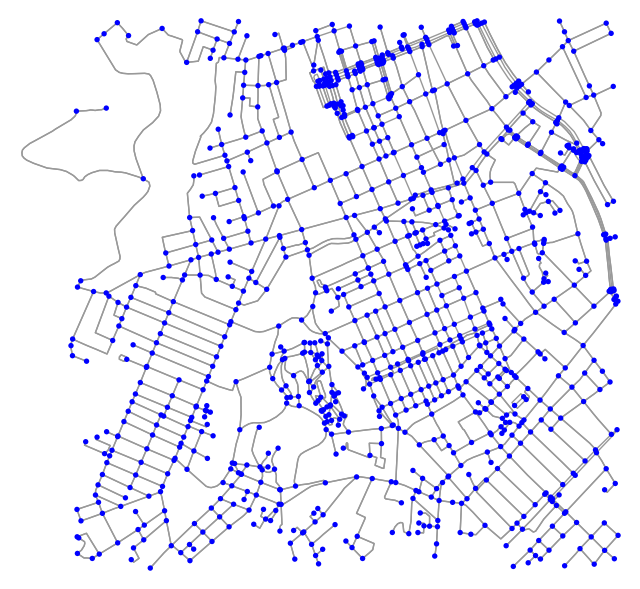

In [3]:
G2 = ox.graph_from_point(center_point=(43.1908875, 140.9951859), network_type='all', dist=1000, simplify=True)
fig, ax = ox.plot_graph(G2,node_color='blue',bgcolor='white')
G2_proj = ox.project_graph(G2)
G2_und = G2_proj.to_undirected()


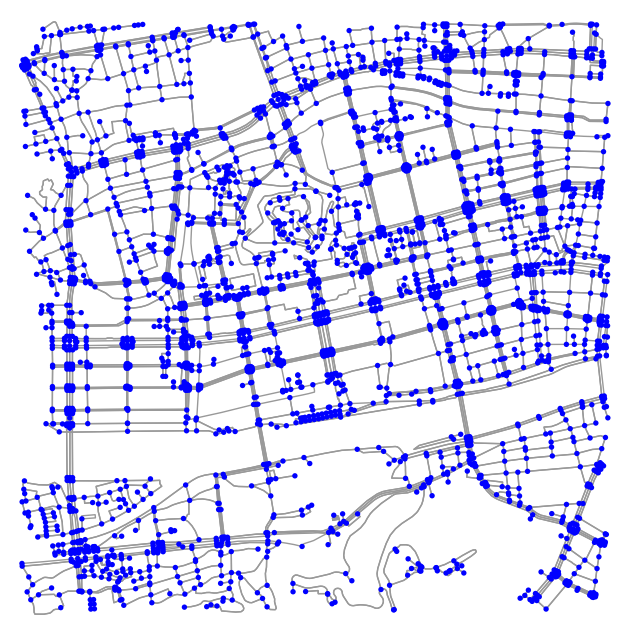

In [4]:
G3 = ox.graph_from_point(center_point=(33.5581452, 133.5319937), network_type='all', dist=1000, simplify=True)
fig, ax = ox.plot_graph(G3,node_color='blue',bgcolor='white')
G3_proj = ox.project_graph(G3)
G3_und = G3_proj.to_undirected()


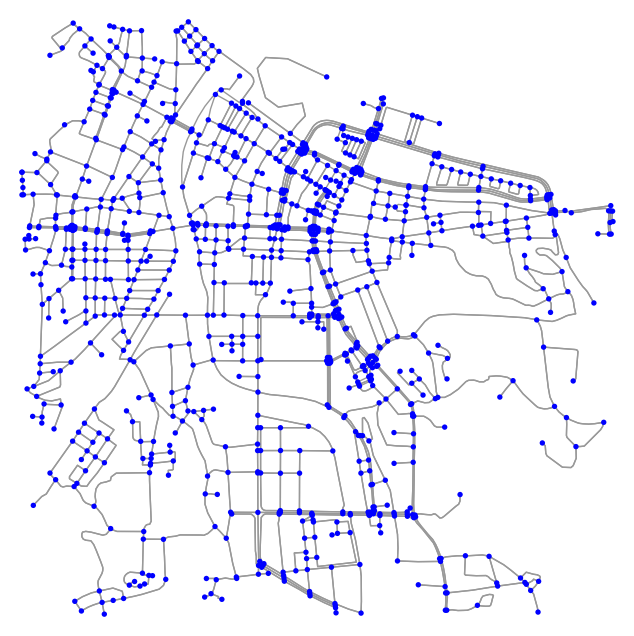

In [5]:
G4 = ox.graph_from_point(center_point=(37.3910308,136.9047961), network_type='all', dist=1000, simplify=True)
fig, ax = ox.plot_graph(G4,node_color='blue',bgcolor='white')
G4_proj = ox.project_graph(G4)
G4_und = G4_proj.to_undirected()


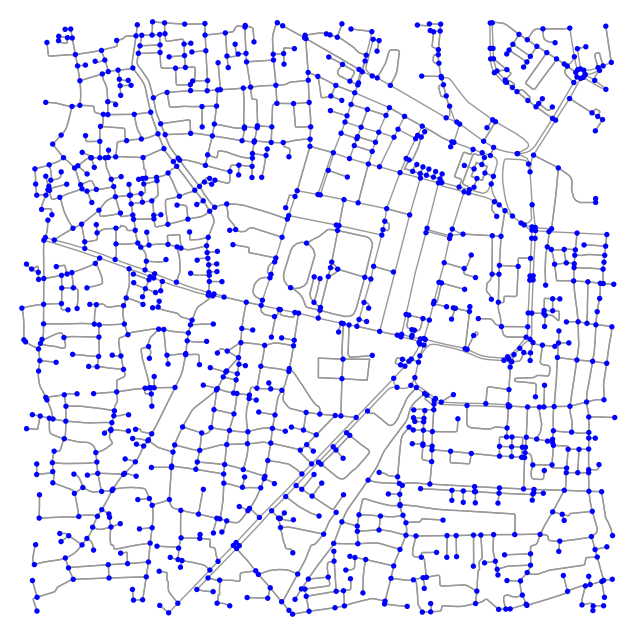

In [6]:
G5 = ox.graph_from_point(center_point=(5.5485879, 95.3137873), network_type='all', dist=1000, simplify=True)
fig, ax = ox.plot_graph(G5,node_color='blue',bgcolor='white')
G5_proj = ox.project_graph(G5)
G5_und = G5_proj.to_undirected()


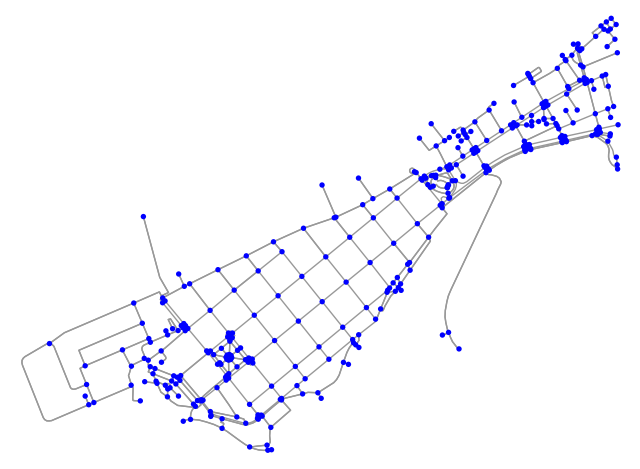

In [7]:
G6 = ox.graph_from_point(center_point=(-12.0716443, -77.1622644), network_type='all', dist=1000, simplify=True)
fig, ax = ox.plot_graph(G6,node_color='blue',bgcolor='white')
G6_proj = ox.project_graph(G6)
G6_und = G6_proj.to_undirected()



In [17]:
g_und = nx.Graph(G_und)
print(nx.number_of_nodes(g_und),nx.number_of_edges(g_und))
g2_und = nx.Graph(G2_und)
print(nx.number_of_nodes(g2_und),nx.number_of_edges(g2_und))
g3_und = nx.Graph(G3_und)
print(nx.number_of_nodes(g3_und),nx.number_of_edges(g3_und))
g4_und = nx.Graph(G4_und)
print(nx.number_of_nodes(g4_und),nx.number_of_edges(g4_und))
g5_und = nx.Graph(G5_und)
print(nx.number_of_nodes(g5_und),nx.number_of_edges(g5_und))
g6_und = nx.Graph(G6_und)
print(nx.number_of_nodes(g6_und),nx.number_of_edges(g6_und))

1523 1889
1074 1558
3258 5065
1049 1558
1184 1502
365 535


In [8]:
G_und2 = nx.MultiGraph(nx.Graph(G_und))
print(nx.number_of_nodes(G_und2),nx.number_of_edges(G_und2))
G2_und2 = nx.MultiGraph(nx.Graph(G2_und))
print(nx.number_of_nodes(G2_und2),nx.number_of_edges(G2_und2))
G3_und2 = nx.MultiGraph(nx.Graph(G3_und))
print(nx.number_of_nodes(G3_und2),nx.number_of_edges(G3_und2))
G4_und2 = nx.MultiGraph(nx.Graph(G4_und))
print(nx.number_of_nodes(G4_und2),nx.number_of_edges(G4_und2))
G5_und2 = nx.MultiGraph(nx.Graph(G5_und))
print(nx.number_of_nodes(G5_und2),nx.number_of_edges(G5_und2))
G6_und2 = nx.MultiGraph(nx.Graph(G6_und))
print(nx.number_of_nodes(G6_und2),nx.number_of_edges(G6_und2))

1523 1889
1074 1558
3258 5065
1049 1558
1184 1502
365 535


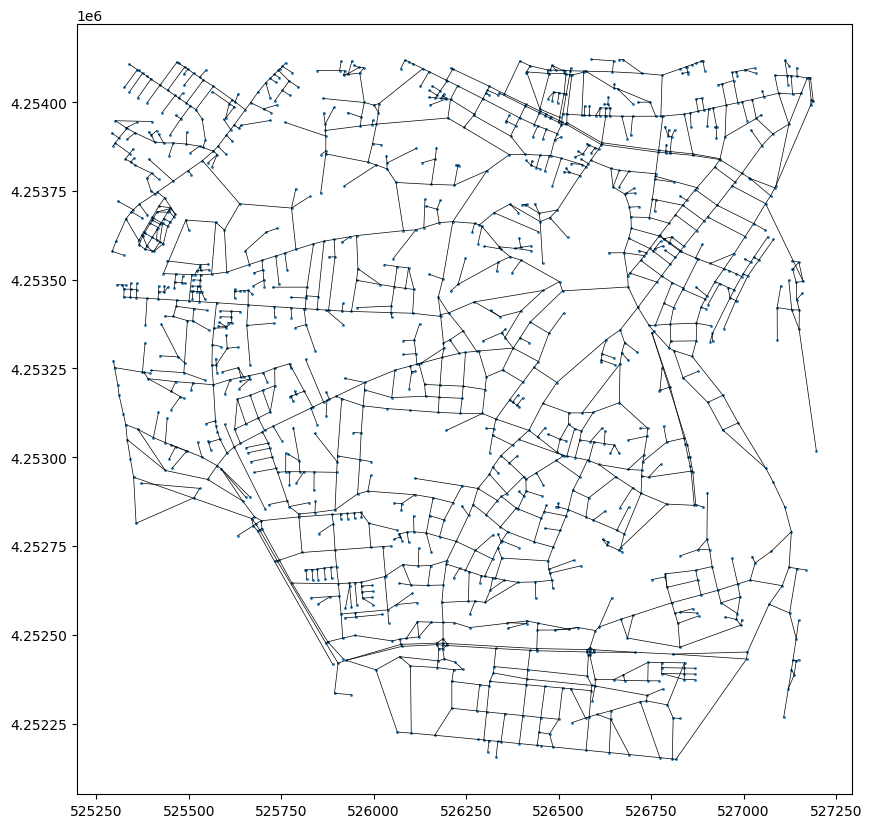

In [18]:
g_und_nodes = pd.DataFrame(g_und.nodes(data=True))
g_und_nodes['y']=g_und_nodes[1].apply(lambda x: x['y']).astype(float)
g_und_nodes['x']=g_und_nodes[1].apply(lambda x: x['x']).astype(float)
g_und_nodes['osmid']=g_und_nodes[0].astype(int)
g_und_nodes.drop(1,axis=1,inplace=True)
g_und_nodes.index=g_und_nodes[0]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(g_und_nodes['x'],g_und_nodes['y'],s=1)
# add the edges of the graph
for edge in g_und.edges():
    x=[g_und_nodes.loc[edge[0]]['x'],g_und_nodes.loc[edge[1]]['x']]
    y=[g_und_nodes.loc[edge[0]]['y'],g_und_nodes.loc[edge[1]]['y']] 
    plt.plot(x,y,'k-',linewidth=0.5)

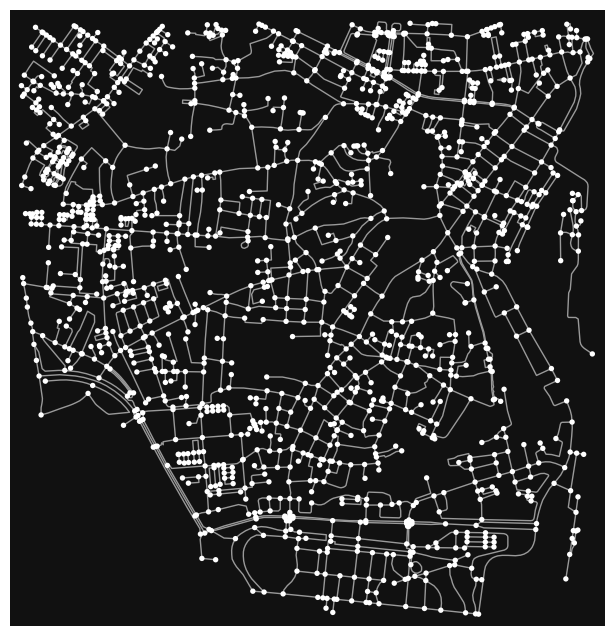

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [21]:
ox.plot_graph(G_und2)

In [10]:
print(nx.density(G_und2))
print(nx.density(g_und))
print(nx.transitivity(g_und))

0.001629849103065307
0.001629849103065307
0.04164305949008498


In [11]:
n1=g_und.number_of_nodes()
n2=g2_und.number_of_nodes()
n3=g3_und.number_of_nodes()
n4=g4_und.number_of_nodes()
n5=g5_und.number_of_nodes()
n6=g6_und.number_of_nodes()
e1=g_und.number_of_edges()
e2=g2_und.number_of_edges()
e3=g3_und.number_of_edges()
e4=g4_und.number_of_edges()
e5=g5_und.number_of_edges()
e6=g6_und.number_of_edges()
c1=e1/(3*(n1-2))
c2=e2/(3*(n2-2))
c3=e3/(3*(n3-2))
c4=e4/(3*(n4-2))
c5=e5/(3*(n5-2))
c6=e6/(3*(n6-2))

In [12]:
p1=pd.Series(nx.pagerank(g_und))
p1.to_csv("page rank1.csv")
p2=pd.Series(nx.pagerank(g2_und))
p2.to_csv("page rank2.csv")
p3=pd.Series(nx.pagerank(g3_und))
p3.to_csv("page rank3.csv")
p4=pd.Series(nx.pagerank(g4_und))
p4.to_csv("page rank4.csv")
p5=pd.Series(nx.pagerank(g5_und))
p5.to_csv("page rank5.csv")
p6=pd.Series(nx.pagerank(g6_und))
p6.to_csv("page rank6.csv")
 #2166925996
#1644237911
# #5303394931
  #11494769981
   #764419156
  #3042136183

In [16]:
df = pd.DataFrame(index=["ishinomaki","otaru","kochi","noto","sumatora","peru"])
df["node"]=[g_und.number_of_nodes(),g2_und.number_of_nodes(),g3_und.number_of_nodes(),g4_und.number_of_nodes(),g5_und.number_of_nodes(),g6_und.number_of_nodes()]
df["edge"]=[g_und.number_of_edges(),g2_und.number_of_edges(),g3_und.number_of_edges(),g4_und.number_of_edges(),g5_und.number_of_edges(),g6_und.number_of_edges()]
df["density"]=[nx.density(g_und),nx.density(g2_und),nx.density(g3_und),nx.density(g4_und),nx.density(g5_und),nx.density(g6_und),]
df["degree correlation"]=[nx.degree_pearson_correlation_coefficient(g_und),nx.degree_pearson_correlation_coefficient(g2_und),nx.degree_pearson_correlation_coefficient(g3_und),nx.degree_pearson_correlation_coefficient(g4_und),nx.degree_pearson_correlation_coefficient(g5_und),nx.degree_pearson_correlation_coefficient(g6_und)]
df["beta index"]=[e1/n1,e2/n2,e3/n3,e4/n4,e5/n5,e6/n6]
df["alpha index"]=[(e1-n1+1)/(2*n1-5),(e2-n2+1)/(2*n2-5),(e3-n3+1)/(2*n3-5),(e4-n4+1)/(2*n4-5),(e5-n5+1)/(2*n5-5),(e6-n6+1)/(2*n6-5)]
df["gamma index"]=[c1,c2,c3,c4,c5,c6]
df["cluster"]=[nx.average_clustering(g_und),nx.average_clustering(g2_und),nx.average_clustering(g3_und),nx.average_clustering(g4_und),nx.average_clustering(g5_und),nx.average_clustering(g6_und)]
df["transitivity"]=[nx.transitivity(g_und),nx.transitivity(g2_und),nx.transitivity(g3_und),nx.transitivity(g4_und),nx.transitivity(g5_und),nx.transitivity(g6_und)]
df["shortest path"]=[nx.average_shortest_path_length(g_und),nx.average_shortest_path_length(g2_und),nx.average_shortest_path_length(g3_und),nx.average_shortest_path_length(g4_und),nx.average_shortest_path_length(g5_und),nx.average_shortest_path_length(g6_und)]
df["page rank"]=[0.0009188932307593691,0.0009636960943304013,0.00035731905576364445,0.0013764740211559367,0.0009553125583106474,0.0029432756261546116]
df["communicability"]=[0.20237786631711957,0.0068661543602551766,0.5766212872495476,0.044672857362124514,0.11656056745394819,0.16113725651285393]
df["degree"]=[g_und.degree(2166925996),g2_und.degree(1644237911),g3_und.degree(5303394931),g4_und.degree(11494769981),g5_und.degree(764419156),g6_und.degree(3042136183)]
print(df)
df.to_csv("graph feature.csv")

            node  edge   density  degree correlation  beta index  alpha index  \
ishinomaki  1523  1889  0.001630            0.016819    1.240315     0.120684   
otaru       1074  1558  0.002704            0.110312    1.450652     0.226318   
kochi       3258  5065  0.000955            0.148416    1.554635     0.277684   
noto        1049  1558  0.002834            0.093461    1.485224     0.243669   
sumatora    1184  1502  0.002145            0.054825    1.268581     0.134998   
peru         365   535  0.008054            0.291186    1.465753     0.235862   

            gamma index   cluster  transitivity  shortest path  page rank  \
ishinomaki     0.413982  0.029219      0.041643      25.448052   0.000919   
otaru          0.484453  0.017101      0.016657      18.906592   0.000964   
kochi          0.518530  0.023859      0.023852      29.962411   0.000357   
noto           0.496020  0.022085      0.022433      18.410789   0.001376   
sumatora       0.423576  0.021396      0.031194

In [14]:
node1,edge1= ox.graph_to_gdfs(G_und2)
node1.to_csv("road_network_node1.csv")

node2,edge2= ox.graph_to_gdfs(G2_und2)
node2.to_csv("road_network_node2.csv")

node3,edge3= ox.graph_to_gdfs(G3_und2)
node3.to_csv("road_network_node3.csv")

node4,edge4= ox.graph_to_gdfs(G4_und2)
node4.to_csv("road_network_node4.csv")

node5,edge5= ox.graph_to_gdfs(G5_und2)
node5.to_csv("road_network_node5.csv")

node6,edge6= ox.graph_to_gdfs(G6_und2)
node6.to_csv("road_network_node6.csv")


In [15]:
df=pd.Series(nx.communicability_betweenness_centrality(nx.Graph(G_und2)))
df.to_csv("G1_communicability_betweenness_centrality.csv")
df2=pd.Series(nx.communicability_betweenness_centrality(nx.Graph(G2_und2)))
df2.to_csv("G2_communicability_betweenness_centrality.csv")
df3=pd.Series(nx.communicability_betweenness_centrality(nx.Graph(G3_und2)))
df3.to_csv("G3_communicability_betweenness_centrality.csv")
df4=pd.Series(nx.communicability_betweenness_centrality(nx.Graph(G4_und2)))
df4.to_csv("G4_communicability_betweenness_centrality.csv")
df5=pd.Series(nx.communicability_betweenness_centrality(nx.Graph(G5_und2)))
df5.to_csv("G5_communicability_betweenness_centrality.csv")
df6=pd.Series(nx.communicability_betweenness_centrality(nx.Graph(G6_und2)))
df6.to_csv("G6_communicability_betweenness_centrality.csv")